In [1]:
import xarray as xr

In [2]:
import xarray as xr
import numpy as np
import pandas as pd

# -----------------------------
# Load ESA vegetation FPC (PFT fractions)
# -----------------------------
esa = xr.open_dataset(
    "/projects/prjs2023/chapter3/lpjml_input/2025_04_87_fpc_from_own_landcover_ESA_2019_overwrite_working.nc",
    decode_times=False
).FPC[0]

# -----------------------------
# Load cropland data (optional, not used in tree % directly)
# -----------------------------
crops = xr.open_dataset(
    "/projects/prjs2023/chapter3/lpjml_input/MAPSPAM_2020_crops_filled_ESA_01deg_v7.nc",
    decode_times=False
).CFTfrac[0]

# -----------------------------
# Tree PFT selection (indices 0–7)
# -----------------------------
tree_pfts = esa.isel(npft=[0, 1, 2, 3, 4, 5, 6, 7])

# -----------------------------
# Compute total tree fraction per grid cell
# -----------------------------
tree_fraction = tree_pfts.sum(dim="npft")

# -----------------------------
# Optional: total vegetation fraction (for normalization option)
# -----------------------------
total_fpc = esa.sum(dim="npft")

# -----------------------------
# Mask non-vegetated cells (ocean / empty land)
# -----------------------------
mask = total_fpc > 0

# -----------------------------
# OPTION 1 (recommended): tree cover as % of total grid cell
# -----------------------------
tree_percent = tree_fraction * 100

# -----------------------------
# OPTION 2 (alternative): tree cover relative to vegetated fraction only
# uncomment if preferred
# tree_percent = (tree_fraction / total_fpc) * 100
# -----------------------------

# Apply mask
tree_percent = tree_percent.where(mask)

# Name for clarity
tree_percent.name = "Tree cover (%)"

# -----------------------------
# OPTIONAL: quick inspection
# -----------------------------
tree_percent



<xarray.DataArray 'Tree cover (%)' (lat: 1397, lon: 3600)> Size: 20MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1397, 3600), dtype=float32)
Coordinates:
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
    time     float64 8B 0.0
Attributes:
    units:          
    standard_name:  FPC
    long_name:      foliage projected cover

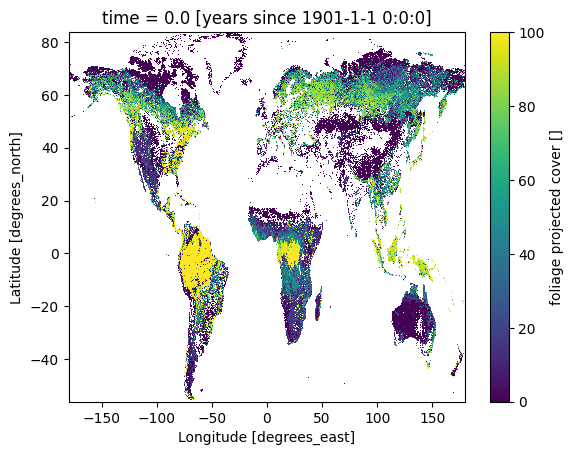

In [3]:
tree_percent.plot()

In [4]:
lc = xr.open_dataset("/projects/prjs2023/chapter3/landcover/C3S-LC-L4-LCCS-Map-01deg_remapnn-P1Y-2022-v2.1.1.nc").lccs_class[0]
lc

<xarray.DataArray 'lccs_class' (lat: 1800, lon: 3600)> Size: 6MB
[6480000 values with dtype=uint8]
Coordinates:
  * lat      (lat) float64 14kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
    time     datetime64[ns] 8B 2022-01-01
Attributes:
    standard_name:        land_cover_lccs
    long_name:            Land cover class defined in LCCS
    flag_colors:          #ffff64 #ffff64 #ffff00 #aaf0f0 #dcf064 #c8c864 #00...
    ancillary_variables:  processed_flag current_pixel_state observation_coun...
    flag_meanings:        no_data cropland_rainfed cropland_rainfed_herbaceou...
    flag_values:          [  0  10  11  12  20  30  40  50  60  61  62  70  7...

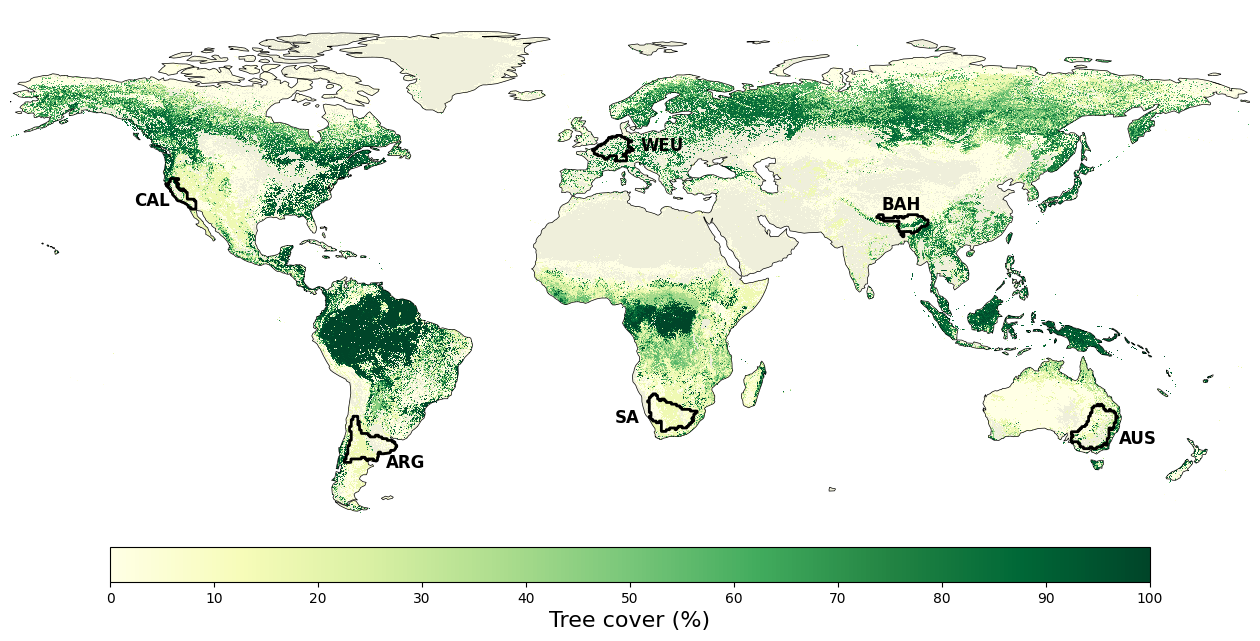

In [25]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# =========================================================
# 3. PLOTTING FUNCTION
# =========================================================

def plot_tree_cover(tree_percent, lc, focus_regions=True, cmap="YlGn", vmin=0, vmax=100):

    contour_color_global = "black"

    fig, ax = plt.subplots(
        figsize=(16, 9),
        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=11)}
    )

    ax.axis('off')

    # --- main map ---
    data_plot = tree_percent.where(lc != 210).where(lc != 200)

    im = data_plot.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND)
    ax.set_ylim([-62, 90])

    # --- colorbar ---
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation='horizontal',
        fraction=0.05,
        pad=0.02,
        aspect=30
    )
    cbar.set_label("Tree cover (%)", fontsize=16)
    cbar.set_ticks(np.arange(0, 110, 10))

    # =====================================================
    # 4. FOCUS REGIONS
    # =====================================================

    if focus_regions:

        regions = ["BAH", "AUS", "WEU", "SA", "ARG", "CAL"]
        mask_folder = "/projects/prjs2023/chapter3/remapped_masks/"

        for region_name in regions:

            if region_name == "BAH":
                reg_lat, reg_lon = slice(19, 37), slice(81, 99)
                mask_file = "mask_Brahmaputra_0_1_degrees.nc"

            elif region_name == "AUS":
                reg_lat, reg_lon = slice(-39.9, -19.9), slice(135, 155)
                mask_file = "mask_AUS_0_1_degrees.nc"

            elif region_name == "WEU":
                reg_lat, reg_lon = slice(41, 57), slice(-2, 14)
                mask_file = "mask_WEU_0_1_degrees.nc"

            elif region_name == "SA":
                reg_lat, reg_lon = slice(-37, -15), slice(13, 35)
                mask_file = "mask_SA_0_1_degrees.nc"

            elif region_name == "ARG":
                reg_lat, reg_lon = slice(-56, -26), slice(-80, -50)
                mask_file = "mask_ARG_0_1_degrees.nc"

            elif region_name == "CAL":
                reg_lat, reg_lon = slice(30, 43), slice(-126, -113)
                mask_file = "mask_CAL_0_1_degrees.nc"

            # --- load region mask ---
            region_mask = xr.open_dataarray(
                f"{mask_folder}{mask_file}"
            ).sel(lat=reg_lat, lon=reg_lon)

            # --- land sea mask ---
            lsm = xr.open_dataset(
                f"{mask_folder}/land-sea-mask_0_1_degrees.nc"
            ).lsm.mean("time").sel(lat=reg_lat, lon=reg_lon)

            # ✔ FIX: safe alignment (NO manual coordinate assignment)
            region_mask = region_mask.interp_like(lsm)

            # --- contour ---
            ax.contour(
                region_mask.lon,
                region_mask.lat,
                np.isnan(region_mask.where(lsm > 0.5)),
                colors=contour_color_global,
                linewidths=2,
                transform=ccrs.PlateCarree()
            )
            
            ax.set_title("", color='black')  

        # =====================================================
        # 5. LABELS
        # =====================================================

        region_labels_pos = {
        "BAH": (84, 32),   # longitude, latitude
        "AUS": (153, -36),
        "WEU": (14, 49),
        "SA": (6.5, -30),
        "ARG": (-60, -43),
        "CAL": (-133, 33)
        }

        for name, (lon, lat) in region_labels_pos.items():
            ax.text(
                lon, lat,
                name,
                transform=ccrs.PlateCarree(),
                fontsize=12,
                fontweight="bold",
                color="black"
            )

    # =====================================================
    # 6. SAVE + SHOW
    # =====================================================

    plt.savefig(
        "tree_cover_percent_focusregions.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()


# =========================================================
# 7. RUN
# =========================================================

plot_tree_cover(tree_percent, lc, focus_regions=True)

In [6]:
import xarray as xr
LPJML = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtmort_new/withfire/output/fpc.nc").FPC.sel(time = "2019").mean("time")#[1:]
LPJML

<xarray.DataArray 'FPC' (pft: 12, lat: 1397, lon: 3600)> Size: 241MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(12, 1397, 3600), dtype=float32)
Coordinates:
  * pft      (pft) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

In [1]:
import xarray as xr
import numpy as np
import pandas as pd

# -----------------------------
# Load ESA vegetation FPC (PFT fractions)
# -----------------------------
esa = xr.open_dataset(
    "/projects/prjs2023/chapter3/lpjml_input/2025_04_87_fpc_from_own_landcover_ESA_2019_overwrite_working.nc",
    decode_times=False
).FPC[0]

LPJML = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtmort_new/withfire/output/fpc.nc").FPC.sel(time = "2019").mean("time")[1:]
LPJML['pft'] = LPJML['pft'] - 2

# -----------------------------
# Tree PFT selection (indices 0–7)
# -----------------------------
tree_pfts = LPJML.isel(pft=[0, 1, 2, 3, 4, 5, 6, 7])

# -----------------------------
# Compute total tree fraction per grid cell
# -----------------------------
tree_fraction = tree_pfts.sum(dim="pft")

# -----------------------------
# Optional: total vegetation fraction (for normalization option)
# -----------------------------
total_fpc = LPJML.sum(dim="pft")

# -----------------------------
# Mask non-vegetated cells (ocean / empty land)
# -----------------------------
mask = total_fpc > 0

# -----------------------------
# OPTION 1 (recommended): tree cover as % of total grid cell
# -----------------------------
tree_percent = tree_fraction * 100

# -----------------------------
# OPTION 2 (alternative): tree cover relative to vegetated fraction only
# uncomment if preferred
# tree_percent = (tree_fraction / total_fpc) * 100
# -----------------------------

# Apply mask
tree_percent = tree_percent.where(mask)

# Name for clarity
tree_percent.name = "Tree cover (%)"

# -----------------------------
# OPTIONAL: quick inspection
# -----------------------------
tree_percent



<xarray.DataArray 'Tree cover (%)' (lat: 1397, lon: 3600)> Size: 20MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1397, 3600), dtype=float32)
Coordinates:
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

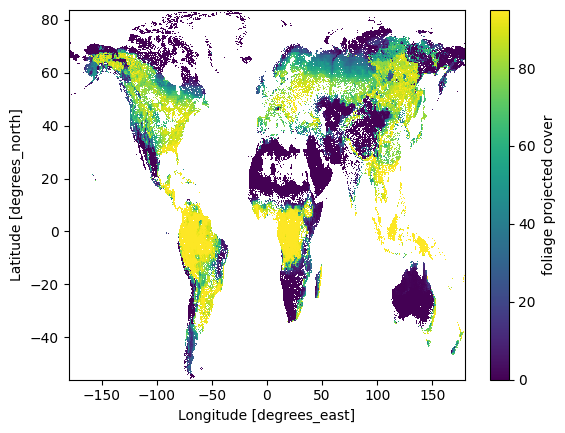

In [2]:
tree_percent.plot()

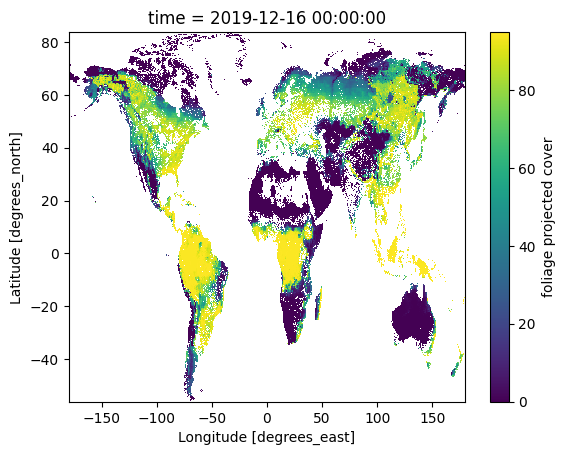

In [5]:
tree_percent.plot()

In [3]:
lc = xr.open_dataset("/projects/prjs2023/chapter3/landcover/C3S-LC-L4-LCCS-Map-01deg_remapnn-P1Y-2022-v2.1.1.nc").lccs_class[0]
lc

<xarray.DataArray 'lccs_class' (lat: 1800, lon: 3600)> Size: 6MB
[6480000 values with dtype=uint8]
Coordinates:
  * lat      (lat) float64 14kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
    time     datetime64[ns] 8B 2022-01-01
Attributes:
    standard_name:        land_cover_lccs
    long_name:            Land cover class defined in LCCS
    flag_colors:          #ffff64 #ffff64 #ffff00 #aaf0f0 #dcf064 #c8c864 #00...
    ancillary_variables:  processed_flag current_pixel_state observation_coun...
    flag_meanings:        no_data cropland_rainfed cropland_rainfed_herbaceou...
    flag_values:          [  0  10  11  12  20  30  40  50  60  61  62  70  7...

In [4]:
import matplotlib as mpl

def discrete_cmap(base_cmap="YlGn", n=20):
    cmap = plt.get_cmap(base_cmap, n)
    norm = mpl.colors.BoundaryNorm(
        boundaries=np.linspace(0, 100, n + 1),
        ncolors=n
    )
    return cmap, norm

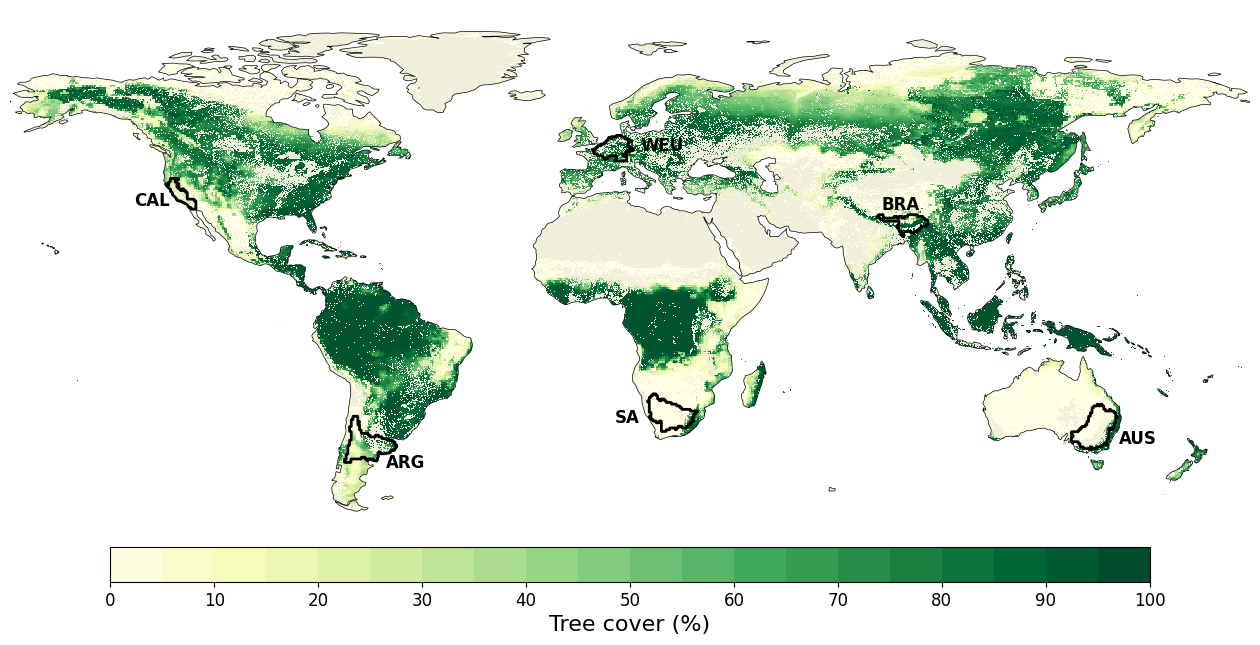

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# =========================================================
# 3. PLOTTING FUNCTION
# =========================================================

def plot_tree_cover(tree_percent, lc, focus_regions=True, cmap="YlGn", vmin=0, vmax=100):

    contour_color_global = "black"

    fig, ax = plt.subplots(
        figsize=(16, 9),
        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=11)}
    )

    ax.axis('off')

    # --- main map ---
    data_plot = tree_percent.where(lc != 210).where(lc != 200)

    im = data_plot.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND)
    ax.set_ylim([-62, 90])

    # --- colorbar ---
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation='horizontal',
        fraction=0.05,
        pad=0.02,
        aspect=30,
        boundaries=np.linspace(0, 100, 21)
    )

    cbar.set_label("Tree cover (%)", fontsize=16)
    cbar.set_ticks(np.arange(0, 110, 10))
    cbar.ax.tick_params(labelsize=12)

    # =====================================================
    # 4. FOCUS REGIONS
    # =====================================================

    if focus_regions:

        regions = ["BRA", "AUS", "WEU", "SA", "ARG", "CAL"]
        mask_folder = "/projects/prjs2023/chapter3/remapped_masks/"

        for region_name in regions:

            if region_name == "BRA":
                reg_lat, reg_lon = slice(19, 37), slice(81, 99)
                mask_file = "mask_Brahmaputra_0_1_degrees.nc"

            elif region_name == "AUS":
                reg_lat, reg_lon = slice(-39.9, -19.9), slice(135, 155)
                mask_file = "mask_AUS_0_1_degrees.nc"

            elif region_name == "WEU":
                reg_lat, reg_lon = slice(41, 57), slice(-2, 14)
                mask_file = "mask_WEU_0_1_degrees.nc"

            elif region_name == "SA":
                reg_lat, reg_lon = slice(-37, -15), slice(13, 35)
                mask_file = "mask_SA_0_1_degrees.nc"

            elif region_name == "ARG":
                reg_lat, reg_lon = slice(-56, -26), slice(-80, -50)
                mask_file = "mask_ARG_0_1_degrees.nc"

            elif region_name == "CAL":
                reg_lat, reg_lon = slice(30, 43), slice(-126, -113)
                mask_file = "mask_CAL_0_1_degrees.nc"

            # --- load region mask ---
            region_mask = xr.open_dataarray(
                f"{mask_folder}{mask_file}"
            ).sel(lat=reg_lat, lon=reg_lon)

            # --- land sea mask ---
            lsm = xr.open_dataset(
                f"{mask_folder}/land-sea-mask_0_1_degrees.nc"
            ).lsm.mean("time").sel(lat=reg_lat, lon=reg_lon)

            # ✔ FIX: safe alignment (NO manual coordinate assignment)
            region_mask = region_mask.interp_like(lsm)

            # --- contour ---
            ax.contour(
                region_mask.lon,
                region_mask.lat,
                np.isnan(region_mask.where(lsm > 0.5)),
                colors=contour_color_global,
                linewidths=2,
                transform=ccrs.PlateCarree()
            )
            
            ax.set_title("", color='black')  

        # =====================================================
        # 5. LABELS
        # =====================================================

        region_labels_pos = {
        "BRA": (84, 32),   # longitude, latitude
        "AUS": (153, -36),
        "WEU": (14, 49),
        "SA": (6.5, -30),
        "ARG": (-60, -43),
        "CAL": (-133, 33)
        }

        for name, (lon, lat) in region_labels_pos.items():
            ax.text(
                lon, lat,
                name,
                transform=ccrs.PlateCarree(),
                fontsize=12,
                fontweight="bold",
                color="black"
            )

    # =====================================================
    # 6. SAVE + SHOW
    # =====================================================

    plt.savefig(
        "tree_cover_percent_focusregions_LPJML.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()


# =========================================================
# 7. RUN
# =========================================================

plot_tree_cover(tree_percent, lc, focus_regions=True)

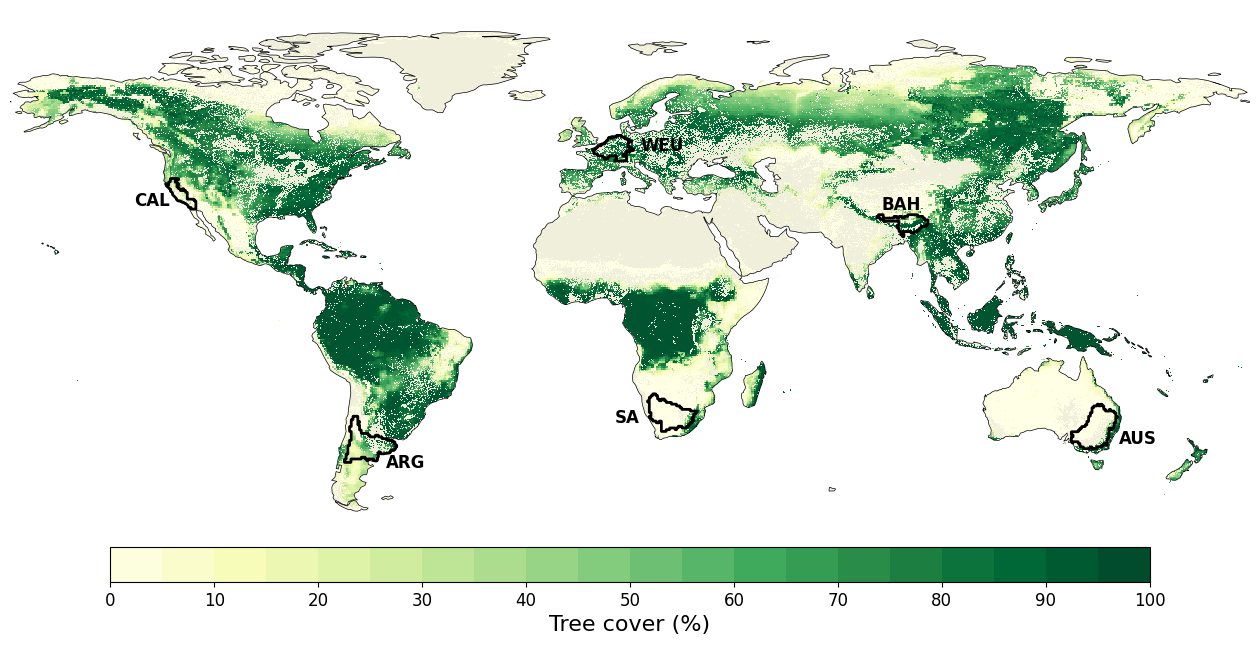

In [9]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# =========================================================
# 3. PLOTTING FUNCTION
# =========================================================

def plot_tree_cover(tree_percent, lc, focus_regions=True, cmap="YlGn", vmin=0, vmax=100):

    contour_color_global = "black"

    fig, ax = plt.subplots(
        figsize=(16, 9),
        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=11)}
    )

    ax.axis('off')

    # --- main map ---
    data_plot = tree_percent.where(lc != 210).where(lc != 200)

    im = data_plot.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND)
    ax.set_ylim([-62, 90])

    # --- colorbar ---
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation='horizontal',
        fraction=0.05,
        pad=0.02,
        aspect=30,
        boundaries=np.linspace(0, 100, 21)
    )

    cbar.set_label("Tree cover (%)", fontsize=16)
    cbar.set_ticks(np.arange(0, 110, 10))
    cbar.ax.tick_params(labelsize=12)

    # =====================================================
    # 4. FOCUS REGIONS
    # =====================================================

    if focus_regions:

        regions = ["BAH", "AUS", "WEU", "SA", "ARG", "CAL"]
        mask_folder = "/projects/prjs2023/chapter3/remapped_masks/"

        for region_name in regions:

            if region_name == "BAH":
                reg_lat, reg_lon = slice(19, 37), slice(81, 99)
                mask_file = "mask_Brahmaputra_0_1_degrees.nc"

            elif region_name == "AUS":
                reg_lat, reg_lon = slice(-39.9, -19.9), slice(135, 155)
                mask_file = "mask_AUS_0_1_degrees.nc"

            elif region_name == "WEU":
                reg_lat, reg_lon = slice(41, 57), slice(-2, 14)
                mask_file = "mask_WEU_0_1_degrees.nc"

            elif region_name == "SA":
                reg_lat, reg_lon = slice(-37, -15), slice(13, 35)
                mask_file = "mask_SA_0_1_degrees.nc"

            elif region_name == "ARG":
                reg_lat, reg_lon = slice(-56, -26), slice(-80, -50)
                mask_file = "mask_ARG_0_1_degrees.nc"

            elif region_name == "CAL":
                reg_lat, reg_lon = slice(30, 43), slice(-126, -113)
                mask_file = "mask_CAL_0_1_degrees.nc"

            # --- load region mask ---
            region_mask = xr.open_dataarray(
                f"{mask_folder}{mask_file}"
            ).sel(lat=reg_lat, lon=reg_lon)

            # --- land sea mask ---
            lsm = xr.open_dataset(
                f"{mask_folder}/land-sea-mask_0_1_degrees.nc"
            ).lsm.mean("time").sel(lat=reg_lat, lon=reg_lon)

            # ✔ FIX: safe alignment (NO manual coordinate assignment)
            region_mask = region_mask.interp_like(lsm)

            # --- contour ---
            ax.contour(
                region_mask.lon,
                region_mask.lat,
                np.isnan(region_mask.where(lsm > 0.5)),
                colors=contour_color_global,
                linewidths=2,
                transform=ccrs.PlateCarree()
            )
            
            ax.set_title("", color='black')  

        # =====================================================
        # 5. LABELS
        # =====================================================

        region_labels_pos = {
        "BAH": (84, 32),   # longitude, latitude
        "AUS": (153, -36),
        "WEU": (14, 49),
        "SA": (6.5, -30),
        "ARG": (-60, -43),
        "CAL": (-133, 33)
        }

        for name, (lon, lat) in region_labels_pos.items():
            ax.text(
                lon, lat,
                name,
                transform=ccrs.PlateCarree(),
                fontsize=12,
                fontweight="bold",
                color="black"
            )

    # =====================================================
    # 6. SAVE + SHOW
    # =====================================================

    plt.savefig(
        "tree_cover_percent_focusregions_LPJML.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()


# =========================================================
# 7. RUN
# =========================================================

plot_tree_cover(tree_percent, lc, focus_regions=True)

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd

# Load ESA vegetation FPC
esa = xr.open_dataset(
    "/projects/prjs2023/chapter3/lpjml_input/2025_04_87_fpc_from_own_landcover_ESA_2019_overwrite_working.nc",
    decode_times=False
).FPC[0]

# Load cropland data (16 rainfed, 16 irrigated classes)
crops = xr.open_dataset(
    "/projects/prjs2023/chapter3/lpjml_input/MAPSPAM_2020_crops_filled_ESA_01deg_v7.nc",
    decode_times=False
).CFTfrac[0]  # select year if needed

# Define all cover names (11 PFTs + 2 crops)
pft_names = [
    "tropical broadleaved evergreen tree",
    "tropical broadleaved raingreen tree",
    "temperate needleleaved evergreen tree",
    "temperate broadleaved evergreen tree",
    "temperate broadleaved summergreen tree",
    "boreal needleleaved evergreen tree",
    "boreal broadleaved summergreen tree",
    "boreal needleleaved summergreen tree",
    "Tropical C4 grass",
    "Temperate C3 grass",
    "Polar C3 grass"
]
all_cover_names = pft_names + ["Rainfed cropland", "Irrigated cropland"]

# Sum cropland types
rainfed = crops.isel(npft=slice(0, 16)).sum(dim="npft")
irrigated = crops.isel(npft=slice(16, 32)).sum(dim="npft")

# Concatenate vegetation and crops
rainfed = rainfed.expand_dims(dim={"npft": 1})
irrigated = irrigated.expand_dims(dim={"npft": 1})
combined = xr.concat([esa, rainfed, irrigated], dim="npft")

# Compute total vegetation fraction
total_fpc = combined.sum(dim="npft")

# Apply mask: only keep cells with vegetation
mask = total_fpc > 0
combined_masked = combined.where(mask)

# Replace NaNs with a very small value just for argmax computation
combined_filled = combined_masked.fillna(-9999)

# Find dominant cover index
dominant_idx = combined_filled.argmax(dim="npft")

# Apply the mask again to ensure invalid (ocean) cells are NaN
dominant_idx = dominant_idx.where(mask)

# Mapping function to group vegetation types
def safe_map(i):
    try:
        i = int(i)
        if i < 0 or i >= len(all_cover_names):
            return "none"
        elif i in [0, 1]:
            return "Tropical trees"
        elif i in [2, 3, 4]:
            return "Temperate trees"
        elif i in [5, 6, 7]:
            return "Boreal trees"
        elif i == 8:
            return "Tropical C4 grass"
        elif i == 9:
            return "Temperate C3 grass"
        elif i == 10:
            return "Polar C3 grass"
        elif i in [11, 12]:
            return "Cropland"
        else:
            return "none"
    except:
        return "none"

# Apply classification
dominant_cover_name = xr.apply_ufunc(
    np.vectorize(safe_map),
    dominant_idx,
    dask='parallelized',
    output_dtypes=[str]
)
dominant_cover_name.name = "Dominant Cover"

# Optionally flatten for use in a DataFrame (e.g., for mapping or summary stats)
cover_flat = dominant_cover_name.values.flatten()
valid_mask = ~pd.isnull(cover_flat)
cover_valid = cover_flat[valid_mask]

df = pd.DataFrame({
    "Dominant Cover": cover_valid
})
df["Dominant Cover"] = pd.Categorical(df["Dominant Cover"], categories=[
    "Tropical trees",
    "Temperate trees",
    "Boreal trees",
    "Tropical C4 grass",
    "Temperate C3 grass",
    "Polar C3 grass",
    "Cropland",
    "none"
], ordered=True)

# Resulting DataFrame:
df
